# Project: Diabetes Detection System
Submited By: Selim Ahmed



## Step 1: Import Libraries

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

## Step 2: Load Dataset from github

In [28]:
url = "https://raw.githubusercontent.com/aronno1920/AI-Engineering/main/Assignment/diabete-dataset.csv"
data = pd.read_csv(url)

## Step 3: Basic Data Cleaning

In [29]:
# Display the first 5 rows
print("Show Top 5 rows:\n", data.head())

Show Top 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [30]:
# Show concise summary of the DataFrame, including column data types and non-null counts
print("\nShow Dataset structure:", data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Show Dataset structure: None


In [31]:
# Display statistical summary (count, mean, std, min, max, etc.) for numeric columns
print("\nShow Data Description:\n", data.describe())


Show Data Description:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0

In [32]:
# Show total number of missing values in each column
print("\nShow Null Values Count in Each Column:\n", data.isnull().sum())


Show Null Values Count in Each Column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Step 4: Exploratory Data Analysis (EDA)

EDA base on feature over Outcome

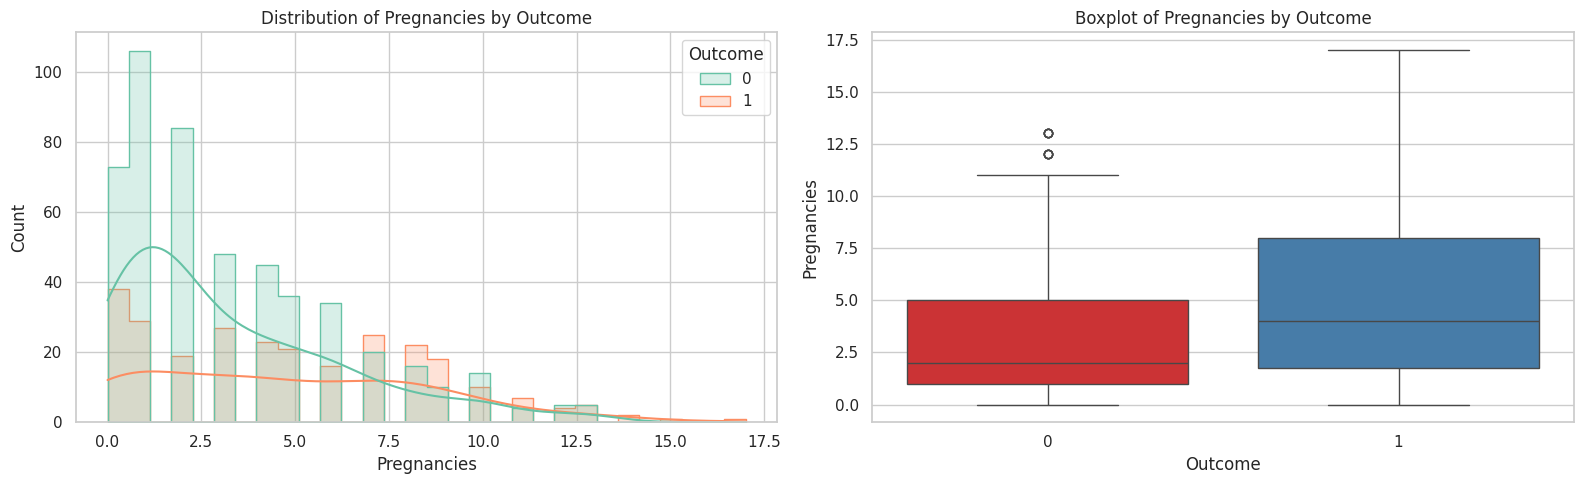

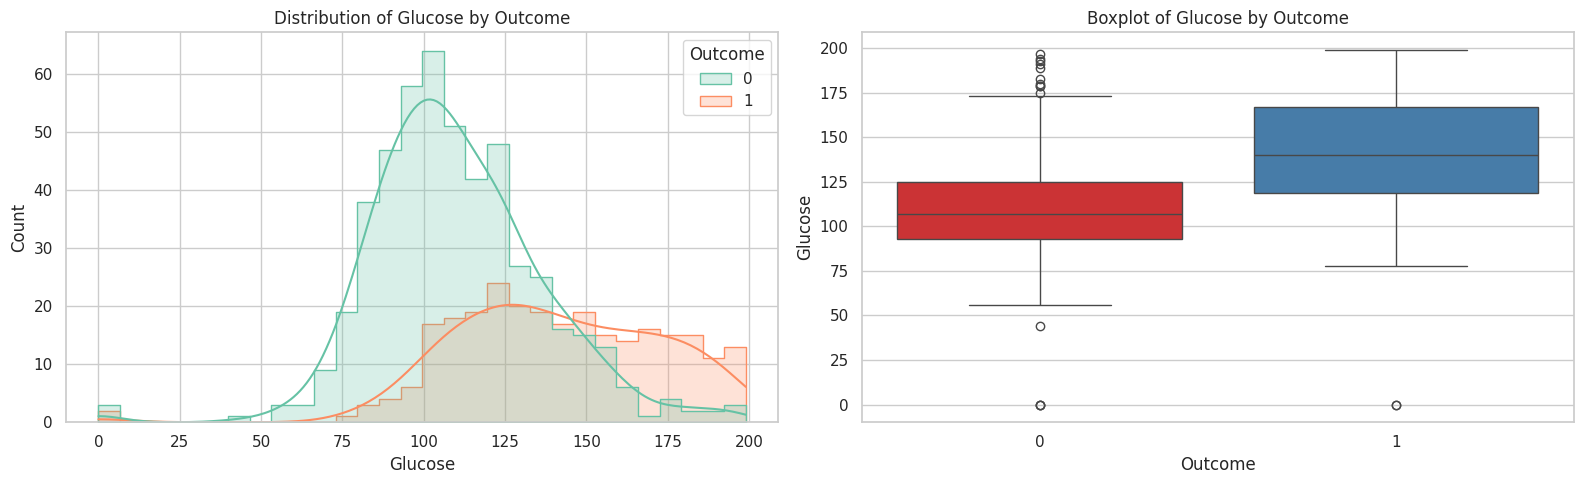

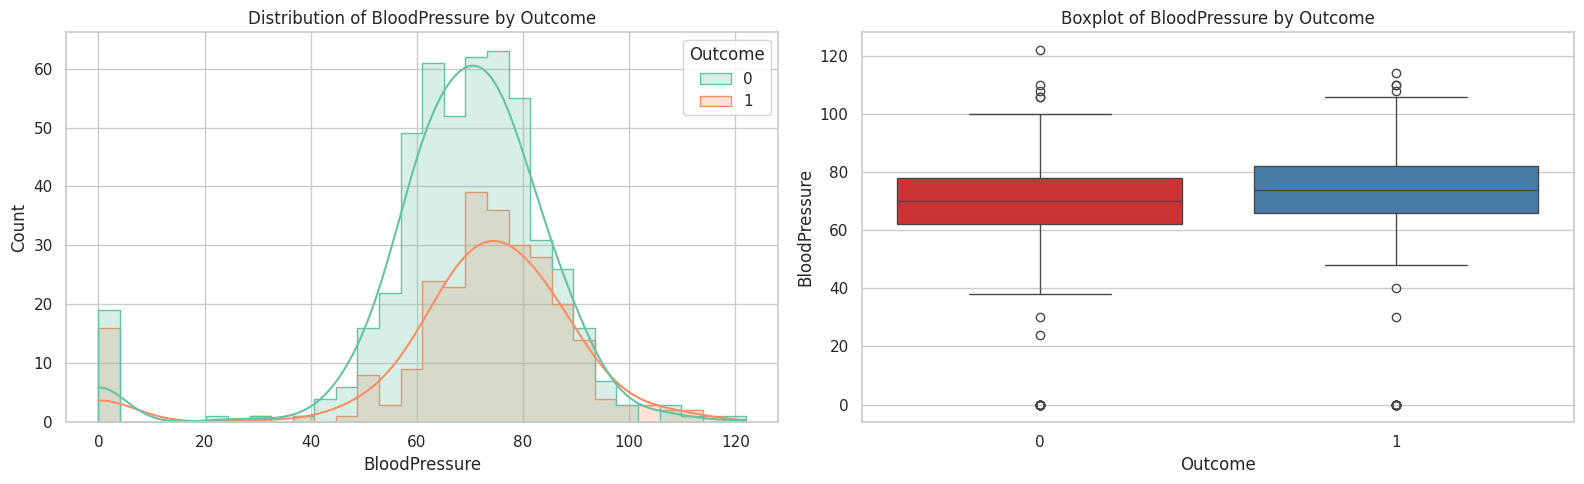

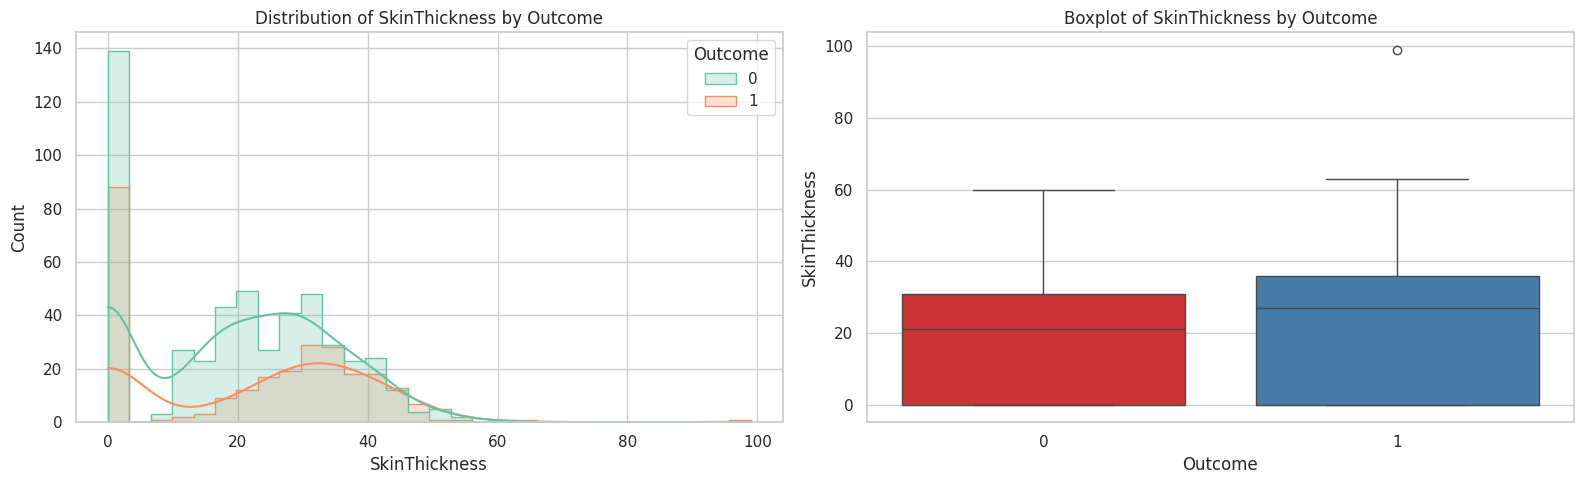

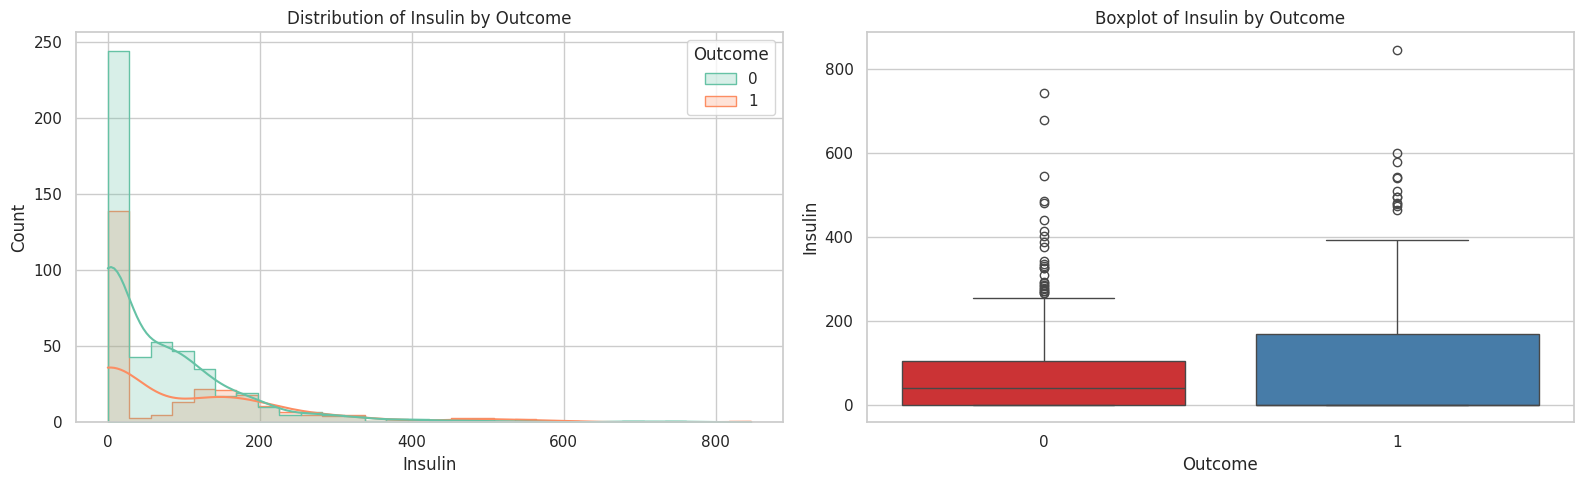

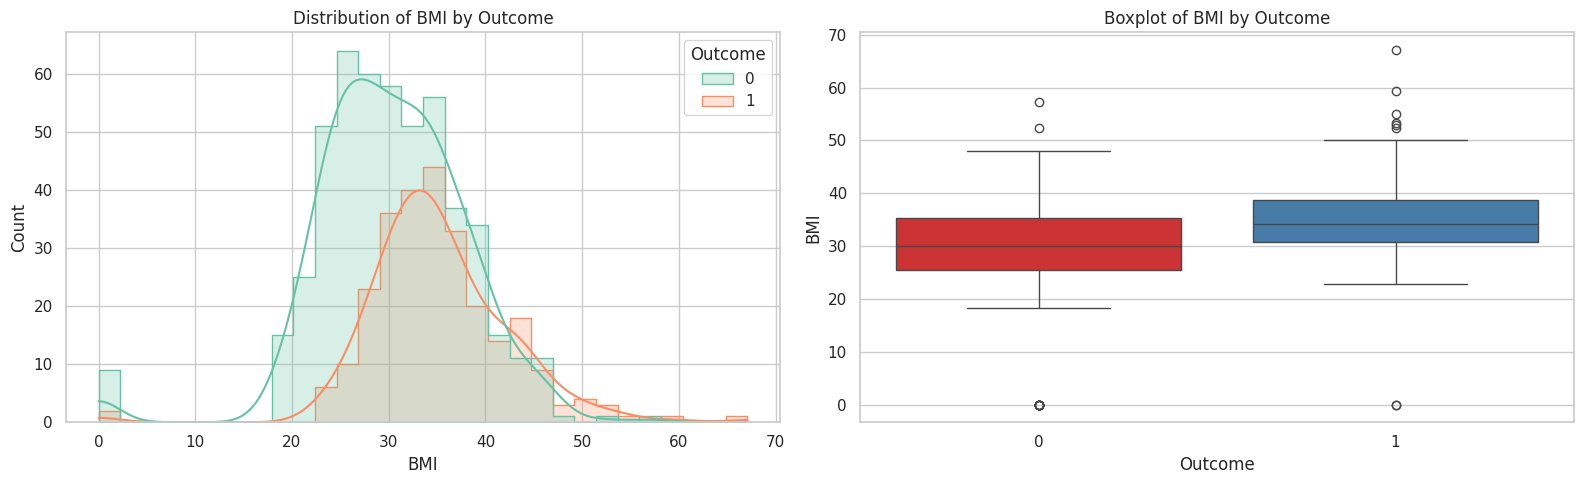

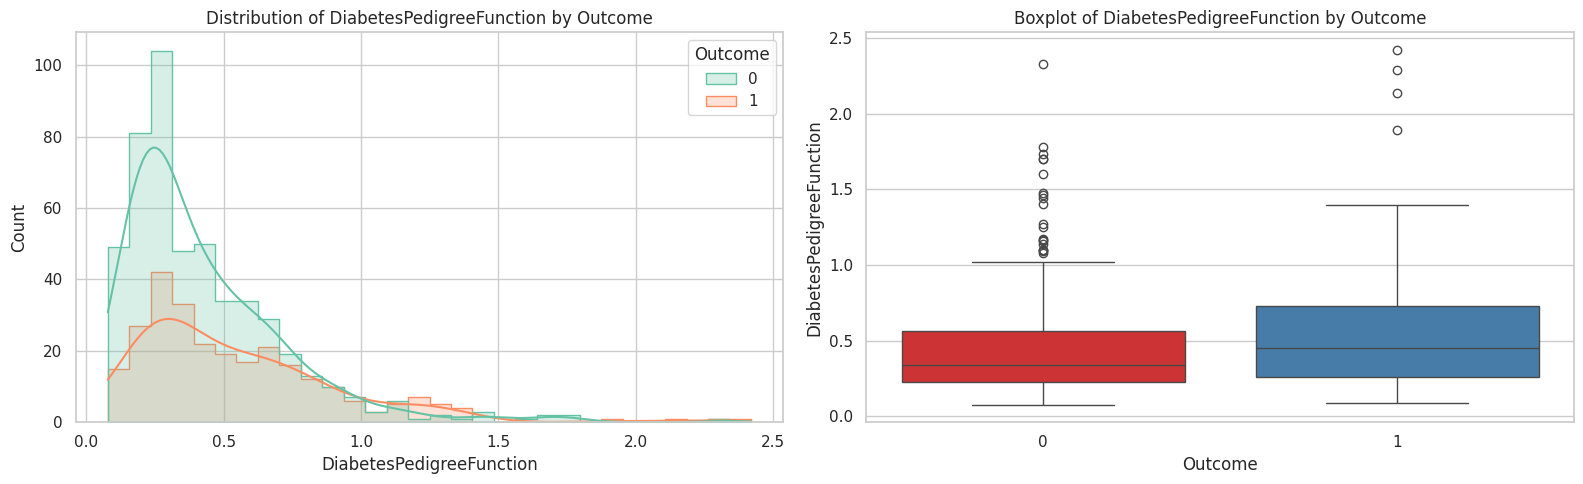

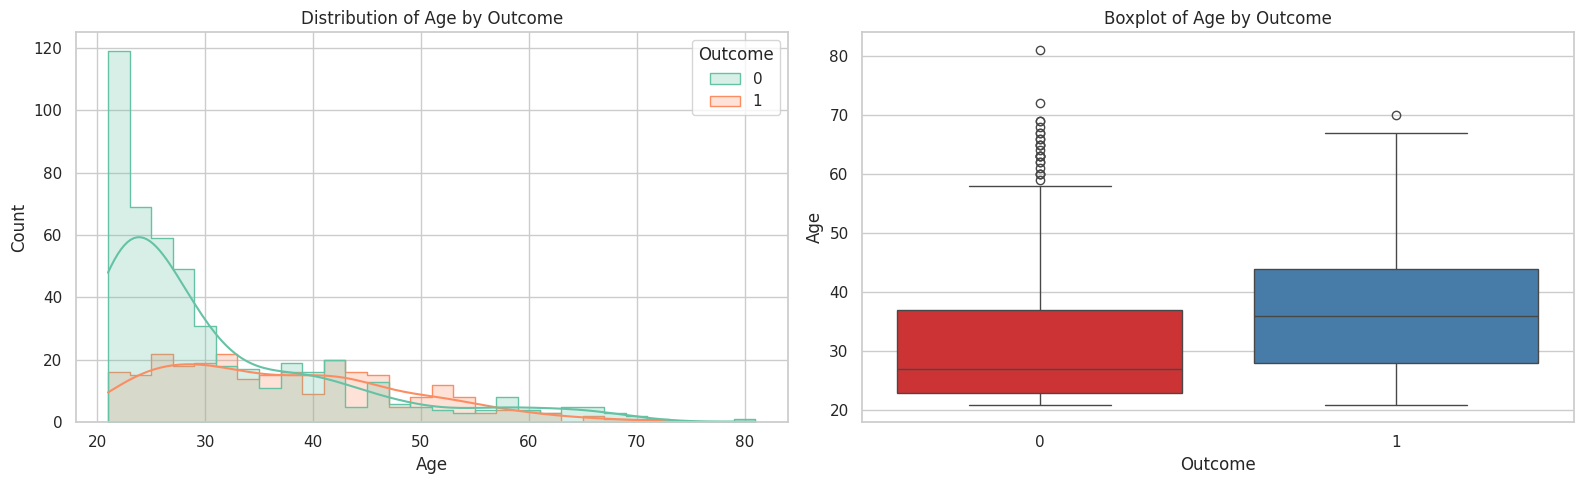

In [33]:
# Set style
sns.set(style="whitegrid")

# List of features (excluding Outcome)
features = [col for col in data.columns if col != 'Outcome']

# Iterate over each feature
for feature in features:
    plt.figure(figsize=(16, 5))

    # Histogram: Feature distribution by Outcome
    plt.subplot(1, 2, 1)
    sns.histplot(data, x=feature, hue="Outcome", kde=True, bins=30, palette="Set2", element="step")
    plt.title(f"Distribution of {feature} by Outcome")

    # Boxplot: See spread and outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x="Outcome", y=feature, data=data, hue="Outcome", palette="Set1")
    plt.title(f"Boxplot of {feature} by Outcome")
    plt.legend([], [], frameon=False)  # Hide legend

    plt.tight_layout()
    plt.show()

Heatmap Correlation base on feature over Outcome

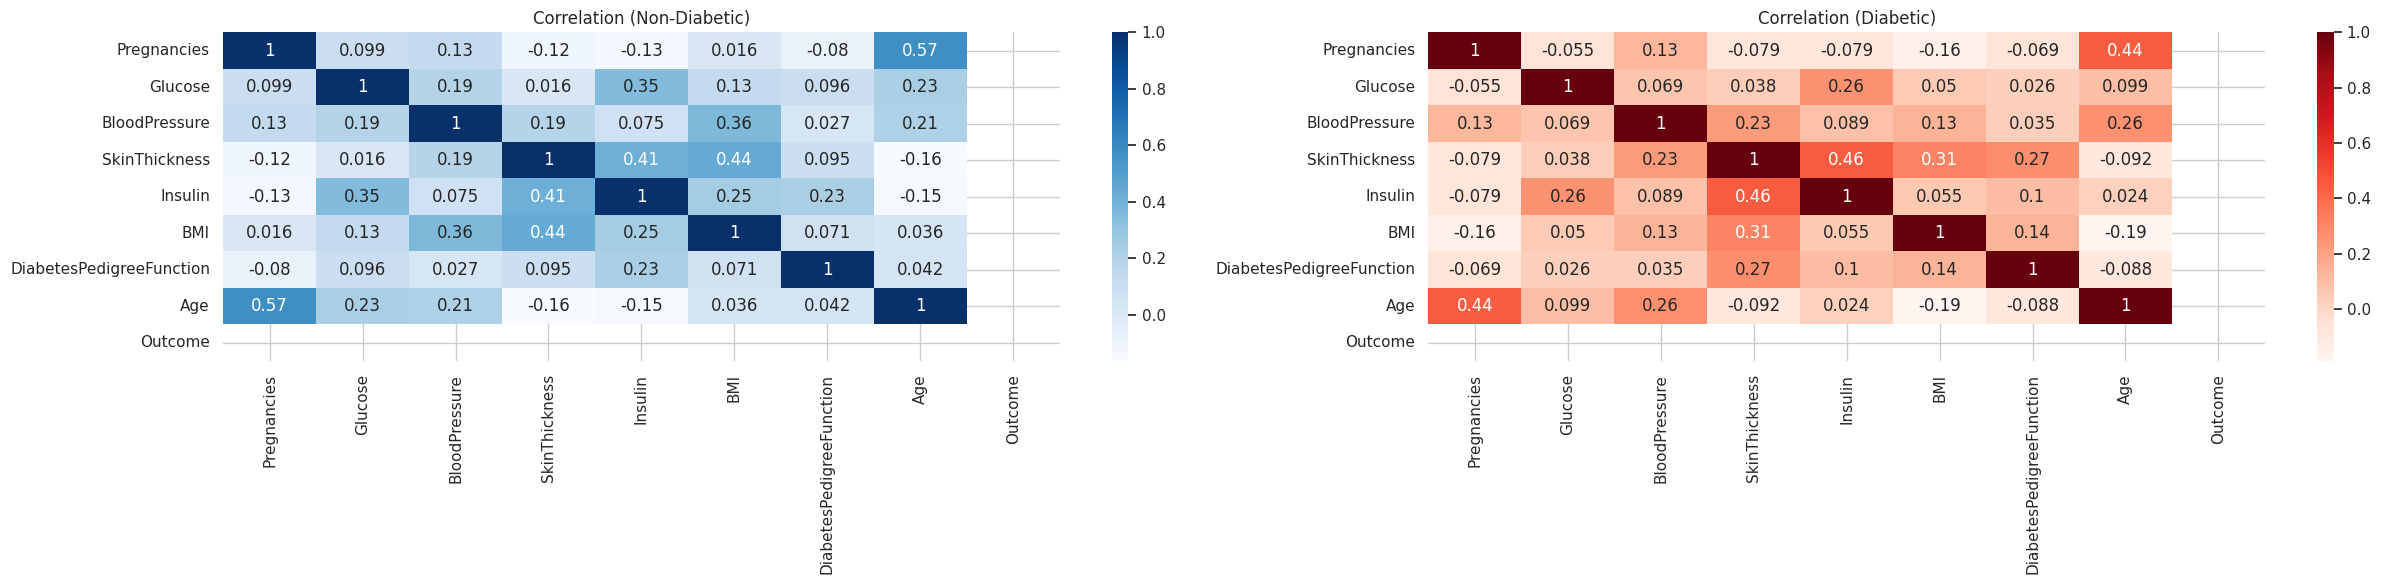

In [34]:
# Correlation matrix for diabetics only
diabetic_corr = data[data["Outcome"] == 1].corr()
non_diabetic_corr = data[data["Outcome"] == 0].corr()

# Plot
plt.figure(figsize=(25, 6))

plt.subplot(1, 2, 1)
sns.heatmap(non_diabetic_corr, annot=True, cmap='Blues')
plt.title("Correlation (Non-Diabetic)")

plt.subplot(1, 2, 2)
sns.heatmap(diabetic_corr, annot=True, cmap='Reds')
plt.title("Correlation (Diabetic)")

plt.tight_layout()
plt.show()


## Step 4: Train-Test Split

In [35]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")


# Convert back to DataFrame for better readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled Training Data:")
display(X_train_scaled.head())

print("\nScaled Test Data:")
display(X_test_scaled.head())

Scaled Training Data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,-0.526397,-1.151398,-3.752683,-1.322774,-0.701206,-4.135256,-0.490735,-1.035940
618,1.588046,-0.276643,0.680345,0.233505,-0.701206,-0.489169,2.415030,1.487101
346,-0.828460,0.566871,-1.265862,-0.090720,0.013448,-0.424522,0.549161,-0.948939
294,-1.130523,1.254179,-1.049617,-1.322774,-0.701206,-1.303720,-0.639291,2.792122
231,0.681856,0.410665,0.572222,1.076490,2.484601,1.838121,-0.686829,1.139095



Scaled Test Data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
668,0.681856,-0.714020,-0.617127,0.817110,0.934749,0.260736,-0.116372,0.878091
324,-0.526397,-0.276643,0.301916,0.752265,-0.701206,0.480535,-0.954231,-1.035940
624,-0.526397,-0.401608,-0.292759,-1.322774,-0.701206,-0.153005,-0.924520,-1.035940
690,1.285983,-0.432849,0.572222,-1.322774,-0.701206,-0.954627,1.149329,0.095078
473,0.983919,0.473147,1.112835,-1.322774,-0.701206,-0.269369,-0.770021,1.487101


In [37]:
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (614, 8)
Testing Data Shape: (154, 8)


Model data fit and print accuracy_score & classification_report

In [38]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Precision": round(report["weighted avg"]["precision"], 4),
        "Recall": round(report["weighted avg"]["recall"], 4),
        "F1-Score": round(report["weighted avg"]["f1-score"], 4),
        "Accuracy": round(acc, 4)
    })


results_df = pd.DataFrame(results)
print(results_df)

                    Model  Precision  Recall  F1-Score  Accuracy
0     Logistic Regression     0.7554  0.7532    0.7542    0.7532
1     K-Nearest Neighbors     0.6874  0.6948    0.6896    0.6948
2           Decision Tree     0.7589  0.7468    0.7503    0.7468
3           Random Forest     0.7219  0.7208    0.7213    0.7208
4  Support Vector Machine     0.7280  0.7338    0.7293    0.7338


## Step 5: Model Evaluate - Confusion Matrix & ROC

### Confusion Matrix

In [39]:
def plot_conf_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Confusion Matrix (Logistic Regression)):
 [[79 20]
 [18 37]]


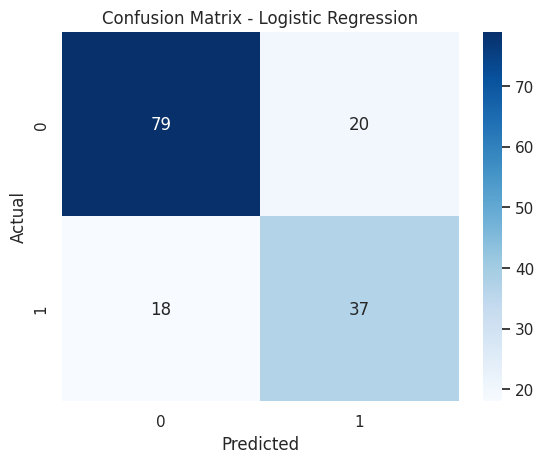


Confusion Matrix (K-Nearest Neighbors)):
 [[79 20]
 [27 28]]


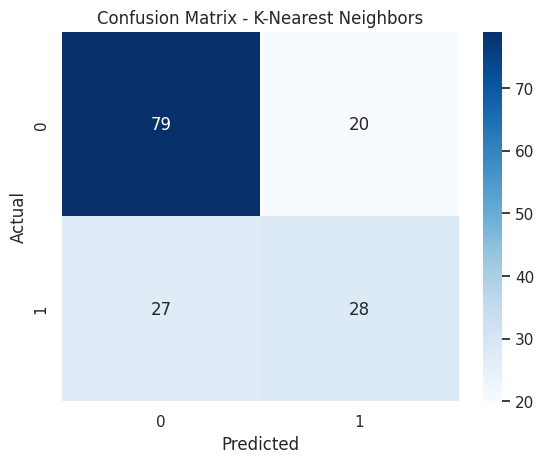


Confusion Matrix (Decision Tree)):
 [[75 24]
 [15 40]]


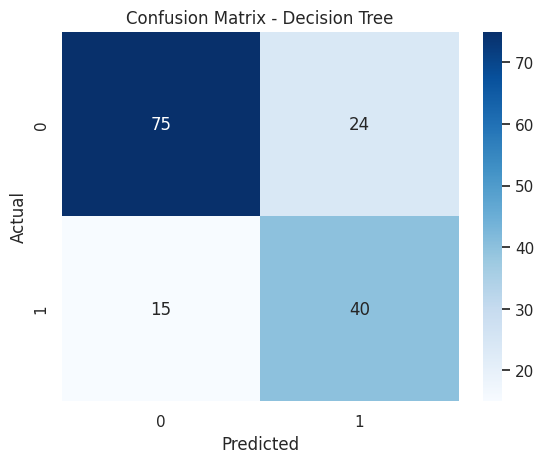


Confusion Matrix (Random Forest)):
 [[77 22]
 [21 34]]


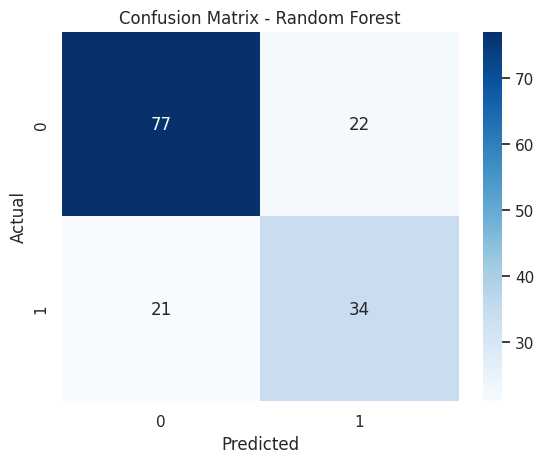


Confusion Matrix (Support Vector Machine)):
 [[82 17]
 [24 31]]


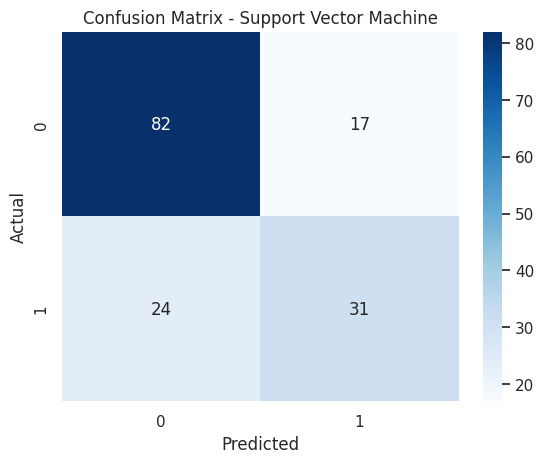

In [40]:
for name, model in models.items():
  y_pred_log = model.predict(X_test_scaled)
  cm_log = confusion_matrix(y_test, y_pred_log)

  print(f"\nConfusion Matrix ({name})):\n", cm_log)
  plot_conf_matrix(y_test, y_pred_log, name)

### ROC AUC

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test, model_name, scaled=True):
    if scaled:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]


    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

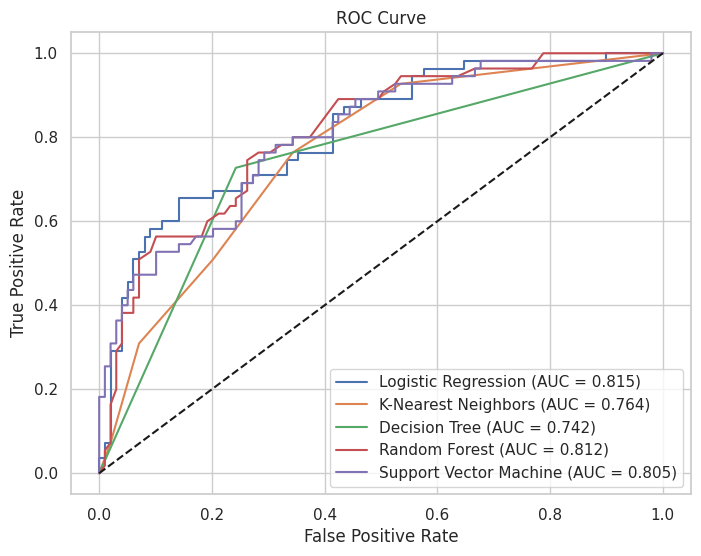

In [42]:
plt.figure(figsize=(8,6))

for name, model in models.items():
  evaluate_model(model, X_test_scaled, y_test, name, scaled=True)

plt.plot([0,1], [0,1], 'k--')  # Diagonal line
plt.show()

## Step 6: Final Output

In [43]:
for name, model in models.items():
  print("Model: ", name)

Model:  Logistic Regression
Model:  K-Nearest Neighbors
Model:  Decision Tree
Model:  Random Forest
Model:  Support Vector Machine


In [44]:
joblib.dump(models["Logistic Regression"], 'diabetes_model.pkl')

['diabetes_model.pkl']

## Step 7: Test Model with Unknown Data

In [48]:
# Load scaler and model
scaler = joblib.load("scaler.pkl")
model = joblib.load("diabetes_model.pkl")

# Define feature names
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# New data as DataFrame
#new_data = pd.DataFrame([[100, 20, 70, 25, 90, 32.0, 0.4, 35]], columns=features)
#new_data = pd.DataFrame([[5, 160, 80, 35, 150, 35.0, 0.6, 45]], columns=features)
new_data = pd.DataFrame([[2, 50, 25, 35, 80, 40.0, 1.2, 52]], columns=features)


# Scale and convert back to DataFrame with same columns
new_data_scaled = scaler.transform(new_data)
new_data_scaled_df = pd.DataFrame(new_data_scaled, columns=features)

# Predict
prediction = model.predict(new_data_scaled_df)
proba = model.predict_proba(new_data_scaled_df)[0][1]

# Output
print("Prediction:", "Diabetes" if prediction[0] == 1 else "No Diabetes")
print(f"Probability of Diabetes: {proba:.2%}")

Prediction: No Diabetes
Probability of Diabetes: 32.70%
